# Pneumonia 3-Class Classifier: DenseNet-121 + CBAM

Merged idea from two projects:
- **cxr-densenet121**: use CXR-domain-specific pretrained weights (via `torchxrayvision`) instead of plain ImageNet
- **CBAM-DenseNet121**: add CBAM attention + classify **3 classes**: Normal / Bacterial Pneumonia / Viral Pneumonia


**Runtime > Change runtime type > GPU** before running.


## 1. Install dependencies

In [1]:
!pip install -q torchxrayvision kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 38.1 MB/s eta 0:00:00


## 2. Download the dataset (Kaggle, via kagglehub)

Uses `tolgadincer/labeled-chest-xray-images` (same Kermany 2018 chest X-ray images,
train/val/test folders with NORMAL/PNEUMONIA subfolders). Public datasets usually
download with `kagglehub` with no extra setup; if you get an auth error, run
`kagglehub.login()` first (needs a Kaggle account + API token from
https://www.kaggle.com/settings).


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print("Path to dataset files:", path)


100%|██████████| 1.17G/1.17G [00:18<00:00, 66.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1


In [3]:
import os

def find_data_root(base_path):
    """kagglehub sometimes nests the data a folder or two deeper than `path` --
    walk down until we find the level that has train/ and test/ subfolders."""
    for root, dirs, _ in os.walk(base_path):
        if "train" in dirs and "test" in dirs:
            return root
    return base_path

DATA_ROOT = find_data_root(path)
print("Dataset ready at:", DATA_ROOT)
print("Contents:", os.listdir(DATA_ROOT))


Dataset ready at: /root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray
Contents: ['train', 'test']


## 3. Imports and config

In [4]:
import os, re, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

CLASS_NAMES = ["Normal", "Bacterial Pneumonia", "Viral Pneumonia"]
NUM_CLASSES = 3

# Toggle: "cxr" uses domain-specific CXR pretrained weights (torchxrayvision),
# "imagenet" uses plain ImageNet pretrained weights (torchvision).
# This one switch is the whole "merged research question" from before.
PRETRAINED_SOURCE = "cxr"   # change to "imagenet" to compare

if PRETRAINED_SOURCE == "cxr":
    # torchxrayvision models expect grayscale input normalized with THEIR
    # convention, not ImageNet RGB stats -- imported here so cell 9 (data
    # transforms) and cell 11 (model) both use the same preprocessing.
    import torchxrayvision as xrv


Using device: cuda


## 4. Dataset (Kermany 2018, 3-class from filenames)

Filenames like `person1_bacteria_1.jpeg` / `person3_virus_5.jpeg` encode the label.


In [5]:
LABEL_PATTERN = re.compile(r"(bacteria|virus)", re.IGNORECASE)
NORMAL, BACTERIAL, VIRAL = 0, 1, 2

def label_from_path(path):
    fname = os.path.basename(path)
    if "NORMAL" in fname.upper():
        return NORMAL
    m = LABEL_PATTERN.search(fname)
    if m:
        return BACTERIAL if m.group(1).lower() == "bacteria" else VIRAL
    return None

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CXRNormalize:
    """Converts a grayscale PIL image to a (1, H, W) tensor using
    torchxrayvision's own normalization convention (roughly [-1024, 1024]),
    matching what the pretrained CXR weights actually saw during training."""
    def __call__(self, pil_img):
        arr = np.array(pil_img).astype(np.float32)
        arr = xrv.datasets.normalize(arr, maxval=255)
        return torch.from_numpy(arr).unsqueeze(0).float()

# Augmentation: rotation + mild affine (translate/zoom) + brightness/contrast
# jitter. NOTE: no horizontal flip -> chest X-rays have anatomical laterality.
if PRETRAINED_SOURCE == "cxr":
    train_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        CXRNormalize(),
    ])
    eval_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        CXRNormalize(),
    ])
else:
    train_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def scan_dir(split_dir):
    """Scan a train/val/test folder (with NORMAL/PNEUMONIA subfolders) into
    a flat list of (path, label) pairs."""
    samples = []
    skipped = 0
    for sub in ("NORMAL", "PNEUMONIA"):
        d = os.path.join(split_dir, sub)
        if not os.path.isdir(d):
            continue
        for fname in os.listdir(d):
            if not fname.lower().endswith((".jpeg", ".jpg", ".png")):
                continue
            path = os.path.join(d, fname)
            label = label_from_path(path)
            if label is None:
                skipped += 1
                continue
            samples.append((path, label))
    print(f"{split_dir}: {len(samples)} samples ({skipped} skipped/unmatched)")
    return samples

class KermanyDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label

    def distribution(self):
        counts = {n: 0 for n in CLASS_NAMES}
        for _, l in self.samples:
            counts[CLASS_NAMES[l]] += 1
        return counts

train_samples_all = scan_dir(os.path.join(DATA_ROOT, "train"))
test_samples      = scan_dir(os.path.join(DATA_ROOT, "test"))
val_dir           = os.path.join(DATA_ROOT, "val")
val_dir_samples   = scan_dir(val_dir) if os.path.isdir(val_dir) else []

# Some dataset releases ship no val/ split at all (or a tiny, near-useless
# one, like Kermany's original 16-image val folder). If we don't have at
# least a reasonably sized val split on disk, carve a stratified one out
# of train instead of relying on it.
if len(val_dir_samples) >= 50:
    train_samples, val_samples = train_samples_all, val_dir_samples
else:
    from sklearn.model_selection import train_test_split
    labels = [l for _, l in train_samples_all]
    train_samples, val_samples = train_test_split(
        train_samples_all, test_size=0.1, random_state=SEED, stratify=labels
    )
    print(f"No usable val/ split found on disk -- carved {len(val_samples)} "
          f"stratified samples out of train ({len(train_samples)} remain for training).")

train_ds = KermanyDataset(train_samples, train_tf)
val_ds   = KermanyDataset(val_samples,   eval_tf)
test_ds  = KermanyDataset(test_samples,  eval_tf)

print("Train distribution:", train_ds.distribution())
print("Val distribution:  ", val_ds.distribution())
print("Test distribution: ", test_ds.distribution())

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/train: 5232 samples (0 skipped/unmatched)
/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/test: 624 samples (0 skipped/unmatched)
No usable val/ split found on disk -- carved 524 stratified samples out of train (4708 remain for training).
Train distribution: {'Normal': 1214, 'Bacterial Pneumonia': 2284, 'Viral Pneumonia': 1210}
Val distribution:   {'Normal': 135, 'Bacterial Pneumonia': 254, 'Viral Pneumonia': 135}
Test distribution:  {'Normal': 234, 'Bacterial Pneumonia': 242, 'Viral Pneumonia': 148}


## 5. Model: DenseNet-121 + CBAM, 3-class head

CBAM = channel attention + spatial attention, inserted after the last DenseNet block.
Kept to ONE insertion point here (simplified vs. the two-insertion-point version discussed earlier).


In [6]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )
        self.spatial_conv = nn.Conv2d(2, 1, spatial_kernel, padding=spatial_kernel // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Channel attention
        ch_att = self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))
        x = x * ch_att
        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sp_att = self.sigmoid(self.spatial_conv(torch.cat([avg_out, max_out], dim=1)))
        return x * sp_att


def build_backbone(pretrained_source):
    if pretrained_source == "cxr":
        # xrv.models.DenseNet already expects 1-channel input, which matches
        # the CXRNormalize transform used above -- no channel-count patching needed.
        model = xrv.models.DenseNet(weights="all")
        features = model.features
    else:
        import torchvision.models as tv
        model = tv.densenet121(weights=tv.DenseNet121_Weights.IMAGENET1K_V1)
        features = model.features
    return features


class DenseNetCBAM3Class(nn.Module):
    def __init__(self, pretrained_source="cxr"):
        super().__init__()
        self.features = build_backbone(pretrained_source)
        self.cbam = CBAM(channels=1024)  # DenseNet-121's final feature depth
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1024, NUM_CLASSES),
        )
        # target layer for Grad-CAM later
        self.gradcam_layer = self.cbam

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = self.cbam(x)
        x = self.pool(x)
        return self.classifier(x)


model = DenseNetCBAM3Class(pretrained_source=PRETRAINED_SOURCE).to(DEVICE)
print(f"Model built with pretrained_source='{PRETRAINED_SOURCE}'")
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
Model built with pretrained_source='cxr'
Trainable parameters: 7081829


## 6. Train

In [7]:
EPOCHS = 15
LR = 1e-4
EARLY_STOP_PATIENCE = 5  # stop if val_loss hasn't improved in this many epochs

# Simple inverse-frequency class weights (Kermany is imbalanced)
counts = train_ds.distribution()
total = sum(counts.values())
class_weights = torch.tensor(
    [total / (NUM_CLASSES * counts[n]) for n in CLASS_NAMES], dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if train_mode:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.append(logits.softmax(dim=1).detach().cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds.argmax(axis=1))
    return total_loss / len(loader.dataset), acc, all_preds, all_labels

best_val_loss = float("inf")
epochs_no_improve = 0
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, _, _ = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc, _, _ = run_epoch(val_loader, train_mode=False)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("  -> saved new best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"No val improvement for {EARLY_STOP_PATIENCE} epochs -- "
                  f"stopping early at epoch {epoch}.")
            break


Epoch 01 | train_loss=1.0080 train_acc=0.4883 | val_loss=0.7820 val_acc=0.6832
  -> saved new best model
Epoch 02 | train_loss=0.7035 train_acc=0.7145 | val_loss=0.5645 val_acc=0.7385
  -> saved new best model
Epoch 03 | train_loss=0.5438 train_acc=0.7634 | val_loss=0.5023 val_acc=0.7805
  -> saved new best model
Epoch 04 | train_loss=0.4852 train_acc=0.7842 | val_loss=0.4876 val_acc=0.7882
  -> saved new best model
Epoch 05 | train_loss=0.4649 train_acc=0.7925 | val_loss=0.4816 val_acc=0.7901
  -> saved new best model
Epoch 06 | train_loss=0.4428 train_acc=0.7972 | val_loss=0.4656 val_acc=0.8111
  -> saved new best model
Epoch 07 | train_loss=0.4275 train_acc=0.8046 | val_loss=0.4694 val_acc=0.7958
Epoch 08 | train_loss=0.4109 train_acc=0.8118 | val_loss=0.4637 val_acc=0.8015
  -> saved new best model
Epoch 09 | train_loss=0.4000 train_acc=0.8173 | val_loss=0.4608 val_acc=0.7939
  -> saved new best model
Epoch 10 | train_loss=0.3877 train_acc=0.8180 | val_loss=0.4587 val_acc=0.7882
  

## 7. Evaluate on the test set

Test accuracy: 0.8910

                     precision    recall  f1-score   support

             Normal       0.99      0.87      0.92       234
Bacterial Pneumonia       0.91      0.92      0.92       242
    Viral Pneumonia       0.75      0.88      0.81       148

           accuracy                           0.89       624
          macro avg       0.88      0.89      0.88       624
       weighted avg       0.90      0.89      0.89       624

Per-class AUC (One-vs-Rest):
  Normal                : AUC = 0.9913
  Bacterial Pneumonia   : AUC = 0.9774
  Viral Pneumonia       : AUC = 0.9540

Confusion matrix (rows = true label, columns = predicted label):
                              Normal  Bacterial Pn  Viral Pneumo
Normal                           203             5            26
Bacterial Pneumonia                1           223            18
Viral Pneumonia                    2            16           130


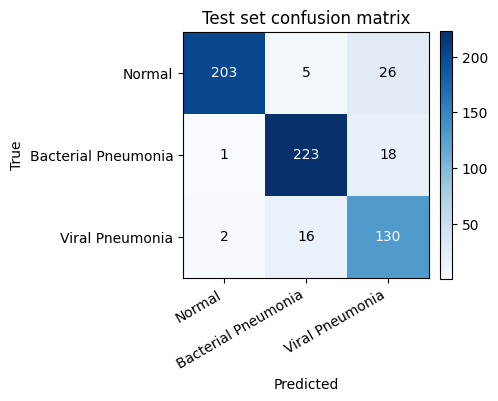

In [8]:
model.load_state_dict(torch.load("best_model.pt"))
test_loss, test_acc, test_probs, test_labels = run_epoch(test_loader, train_mode=False)

print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(test_labels, test_probs.argmax(axis=1), target_names=CLASS_NAMES))

print("Per-class AUC (One-vs-Rest):")
for i, name in enumerate(CLASS_NAMES):
    binary_labels = (test_labels == i).astype(int)
    if len(np.unique(binary_labels)) > 1:
        auc = roc_auc_score(binary_labels, test_probs[:, i])
        print(f"  {name:22s}: AUC = {auc:.4f}")

# Confusion matrix -- shows exactly which classes get confused with each other
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

test_preds = test_probs.argmax(axis=1)
cm = confusion_matrix(test_labels, test_preds)

print("\nConfusion matrix (rows = true label, columns = predicted label):")
header = " " * 22 + "".join(f"{n[:12]:>14s}" for n in CLASS_NAMES)
print(header)
for i, name in enumerate(CLASS_NAMES):
    row = "".join(f"{cm[i, j]:>14d}" for j in range(NUM_CLASSES))
    print(f"{name:22s}{row}")

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Test set confusion matrix")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


## 8. Grad-CAM on one test image



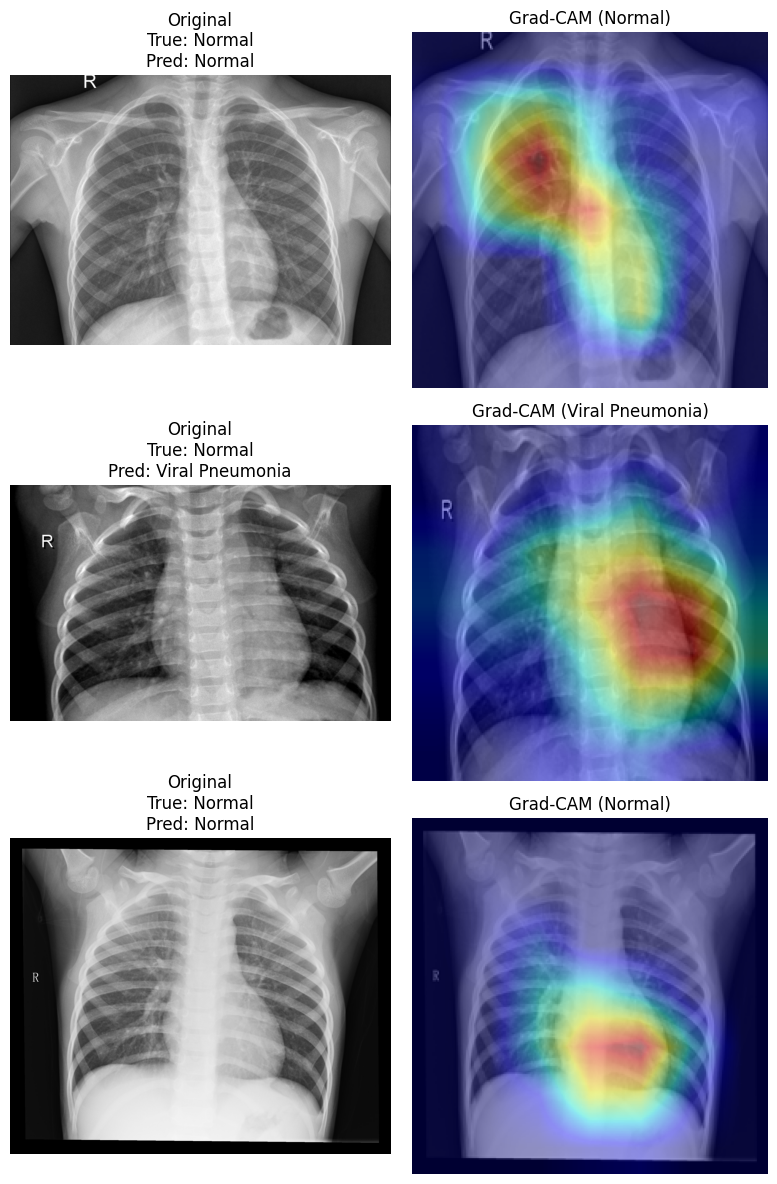

In [9]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Define a generic GradCAM class since importing from torchxrayvision failed
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture activations and gradients
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple; we need the gradient with respect to the output of the layer
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        # Set model to evaluation mode
        self.model.eval()

        # Zero out gradients
        self.model.zero_grad()

        # Forward pass to get output and activations
        output = self.model(input_tensor)

        if class_idx is None:
            # If no specific class is provided, use the predicted class
            class_idx = output.argmax(dim=1).item()

        # Create one-hot vector for the target class
        # Fix: Ensure the index tensor has the same number of dimensions as the self tensor (output)
        one_hot = torch.zeros_like(output).scatter_(1, torch.tensor([[class_idx]], device=input_tensor.device), 1.0)

        # Backward pass to get gradients
        output.backward(gradient=one_hot, retain_graph=True)

        # Get the captured gradients and activations
        guided_gradients = self.gradients
        activations = self.activations

        # Compute weights: global average pool of gradients
        weights = F.adaptive_avg_pool2d(guided_gradients, 1)

        # Compute Grad-CAM map: sum of (weights * activations)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam) # Apply ReLU to only keep positive contributions

        # Interpolate to input image size and normalize
        cam = F.interpolate(cam, input_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.squeeze().cpu().numpy()

model.eval()
# Use the defined GradCAM class
gradcam = GradCAM(model, model.gradcam_layer)

num_images = 3

fig, axes = plt.subplots(num_images, 2, figsize=(8, 4 * num_images))

for i in range(num_images):

    sample_path, sample_label = test_ds.samples[i]
    original = Image.open(sample_path).convert("RGB")

    input_tensor = eval_tf(original).unsqueeze(0).to(DEVICE)

    # Prediction
    with torch.no_grad():
        logits = model(input_tensor)
        pred_class = logits.argmax(dim=1).item()

    # Grad-CAM for predicted class only
    cam = gradcam.generate(input_tensor, class_idx=pred_class)

    # Original image
    axes[i, 0].imshow(original, cmap="gray")
    axes[i, 0].set_title(
        f"Original\nTrue: {CLASS_NAMES[sample_label]}\nPred: {CLASS_NAMES[pred_class]}"
    )
    axes[i, 0].axis("off")

    # Grad-CAM
    axes[i, 1].imshow(original.resize((224, 224)), cmap="gray")
    axes[i, 1].imshow(cam, cmap="jet", alpha=0.4)
    axes[i, 1].set_title(f"Grad-CAM ({CLASS_NAMES[pred_class]})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Notes

- Switch `PRETRAINED_SOURCE` in cell 7 to `"imagenet"` and re-run to compare CXR-specific vs. ImageNet-pretrained weights (the core question from the merged design). Data transforms and the model's input channels adapt automatically.
- The `"cxr"` path uses `torchxrayvision`'s own normalization convention (grayscale, roughly [-1024, 1024] range) instead of ImageNet RGB stats, so the pretrained CXR weights see inputs consistent with their original training.
- Augmentation: rotation, mild translation/zoom, and brightness/contrast jitter. Still no horizontal flip -> chest X-rays have anatomical laterality.
- Early stopping: training stops if `val_loss` hasn't improved for `EARLY_STOP_PATIENCE` (default 5) epochs, instead of always running the full `EPOCHS`.
- Validation split: if the dataset ships no `val/` folder (or a very small one, like Kermany's original 16-image val set), a stratified split is carved automatically out of `train`.
- Label parsing (`label_from_path`) matches on `NORMAL` / `BACTERIA` / `VIRUS` appearing anywhere in the filename, which works for both the original Kermany naming (`person1_bacteria_1.jpeg`) and this dataset's naming (`BACTERIA-8475797-0001.jpeg`). If you point this at yet another dataset mirror, check the printed skipped-sample counts to confirm it's still matching correctly.
- This simplified version skips: multi-seed averaging, DeLong significance testing, and RSNA external validation. Ask for the fuller multi-file version if you need those for a paper-grade study.
- Training up to 15 epochs on ~5,200 images takes roughly 10-20 minutes on a free Colab T4 GPU (less with early stopping).
